In [1]:
import pickle
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [5]:
# get dataloader
import sys
sys.path.insert(0, '../')
from mtr.datasets import build_dataloader
from mtr.config import cfg, cfg_from_list, cfg_from_yaml_file, log_config_to_file
from mtr.utils import common_utils
import datetime
from pathlib import Path

# cfg_file = '../tools/cfgs/challenge/mtr+val_data_withmap_h1s.yaml'
cfg_file = '../tools/cfgs/challenge/mtr+val+ann12_data_withmap_h1sf5s_cluster32.yaml'
output_dir = Path("clustering")
log_file = output_dir / ('log_loaddata_%s.txt' % datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
cfg_from_yaml_file(cfg_file, cfg)
logger = common_utils.create_logger(log_file, rank=cfg.LOCAL_RANK)
train_set, train_loader, train_sampler = build_dataloader(
    dataset_cfg=cfg.DATA_CONFIG,
    batch_size=80,
    dist=False, workers=2,
    logger=logger,
    training=True,
    merge_all_iters_to_one_epoch=False,
    total_epochs=10,
    add_worker_init_fn=None,
)

2024-09-06 00:59:26,369   INFO  Start to load infos from /data/tianhui/Challenge/val_ann12_h1sf5s/processed_scenarios_training_infos.pkl
2024-09-06 00:59:26,369   INFO  Start to load infos from /data/tianhui/Challenge/val_ann12_h1sf5s/processed_scenarios_training_infos.pkl


2024-09-06 00:59:27,066   INFO  Total scenes before filters: 3712
2024-09-06 00:59:27,066   INFO  Total scenes before filters: 3712
2024-09-06 00:59:27,101   INFO  Total scenes after filter_info_by_object_type: 3712
2024-09-06 00:59:27,101   INFO  Total scenes after filter_info_by_object_type: 3712
2024-09-06 00:59:27,154   INFO  Total scenes after filters: 3712
2024-09-06 00:59:27,154   INFO  Total scenes after filters: 3712


In [6]:
# Access the dataset from the dataloader
dataset_from_dataloader = train_loader.dataset
# Now you can use dataset_from_dataloader as needed
print(f"Dataset: {dataset_from_dataloader}")
print(f"Number of samples in the dataset: {len(dataset_from_dataloader)}")

Dataset: <mtr.datasets.challenge.challenge_dataset_withmap_4cls.ChallengeDatasetWithMap_4Cls object at 0x7f061d18b4c0>
Number of samples in the dataset: 3712


In [7]:
all_center_gt_trajs = []
all_center_gt_trajs_mask = []
all_center_objects_type = []
all_scenario_id = []

# Iterate over the DataLoader
for batch in train_loader:

    center_gt_trajs = batch['input_dict']['center_gt_trajs']
    center_gt_trajs_mask = batch['input_dict']['center_gt_trajs_mask']
    center_objects_type = batch['input_dict']['center_objects_type']
    scenario_id = batch['input_dict']['scenario_id']

    all_center_gt_trajs.append(center_gt_trajs)
    all_center_gt_trajs_mask.append(center_gt_trajs_mask)
    all_center_objects_type.append(center_objects_type)
    all_scenario_id.append(scenario_id)


In [8]:
all_center_gt_trajs_mask_concat = torch.cat(all_center_gt_trajs_mask, dim=0)
all_center_gt_trajs_concat = torch.cat(all_center_gt_trajs, dim=0)
all_center_objects_type_concat = np.concatenate(all_center_objects_type)
print(all_center_gt_trajs_concat.shape, all_center_gt_trajs_mask_concat.shape, all_center_objects_type_concat.shape)

torch.Size([10598, 50, 4]) torch.Size([10598, 50]) (10598,)


In [9]:
intention_points_dict = {}

/data/miniconda3/envs/mtr_vis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


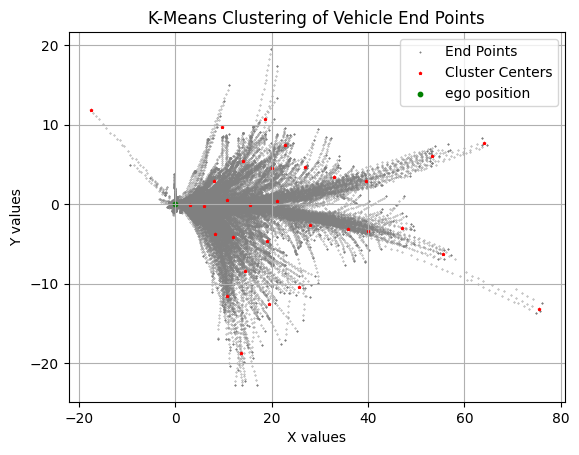

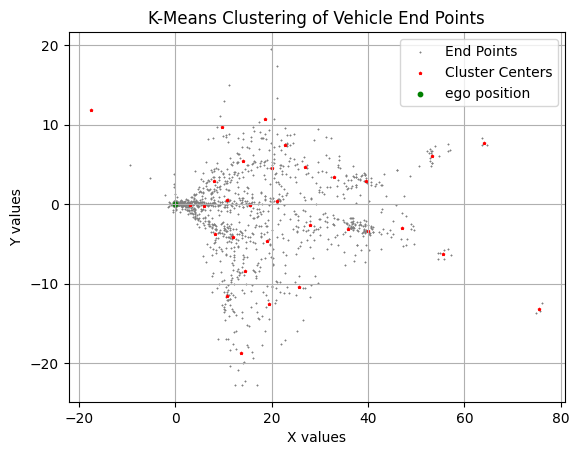

In [10]:
# get intention points for TYPE_VEHICLE
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_VEHICLE':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32  #64

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
vehicle_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_VEHICLE'] = vehicle_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_vehicle_mask = (all_center_objects_type_concat == 'TYPE_VEHICLE')
filtered_vehicle_trajs = all_center_gt_trajs_concat[filtered_vehicle_mask]

filtered_vehicle_trajs = filtered_vehicle_trajs.reshape(-1, 4)
traj_x = filtered_vehicle_trajs[:, 0].cpu().numpy()
traj_y = filtered_vehicle_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(vehicle_cluster_centers[:, 0], vehicle_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Vehicle End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(vehicle_cluster_centers[:, 0], vehicle_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Vehicle End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

/data/miniconda3/envs/mtr_vis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


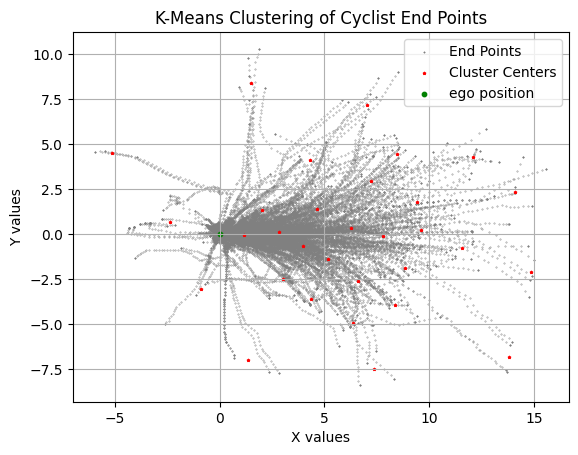

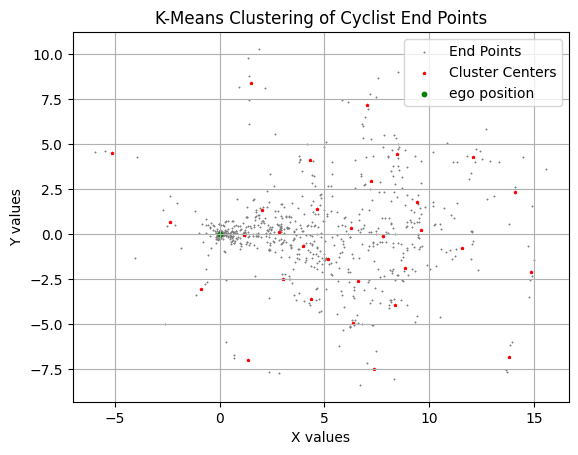

In [11]:
# get intention points for TYPE_CYCLIST
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_CYCLIST':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
cyclist_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_CYCLIST'] = cyclist_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_cyclist_mask = (all_center_objects_type_concat == 'TYPE_CYCLIST')
filtered_cyclist_trajs = all_center_gt_trajs_concat[filtered_cyclist_mask]

filtered_cyclist_trajs = filtered_cyclist_trajs.reshape(-1, 4)
traj_x = filtered_cyclist_trajs[:, 0].cpu().numpy()
traj_y = filtered_cyclist_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(cyclist_cluster_centers[:, 0], cyclist_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Cyclist End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(cyclist_cluster_centers[:, 0], cyclist_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Cyclist End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

/data/miniconda3/envs/mtr_vis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


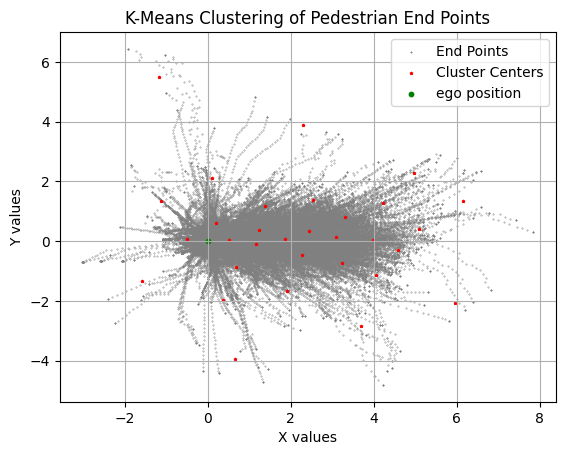

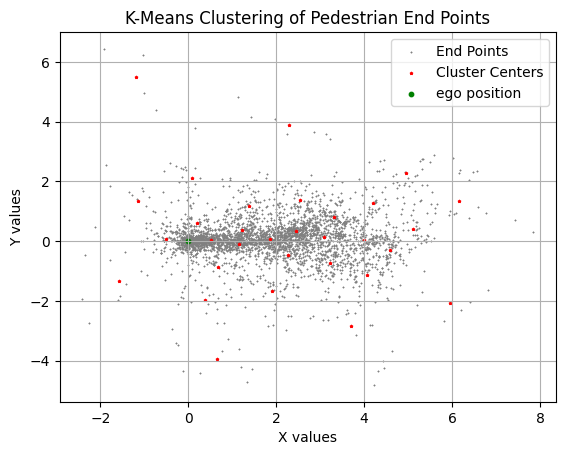

In [12]:
# get intention points for TYPE_PEDESTRIAN
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_PEDESTRIAN':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
pedestrian_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_PEDESTRIAN'] = pedestrian_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_pedestrian_mask = (all_center_objects_type_concat == 'TYPE_PEDESTRIAN')
filtered_pedestrian_trajs = all_center_gt_trajs_concat[filtered_pedestrian_mask]

filtered_pedestrian_trajs = filtered_pedestrian_trajs.reshape(-1, 4)
traj_x = filtered_pedestrian_trajs[:, 0].cpu().numpy()
traj_y = filtered_pedestrian_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Pedestrian End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Pedestrian End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

/data/miniconda3/envs/mtr_vis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


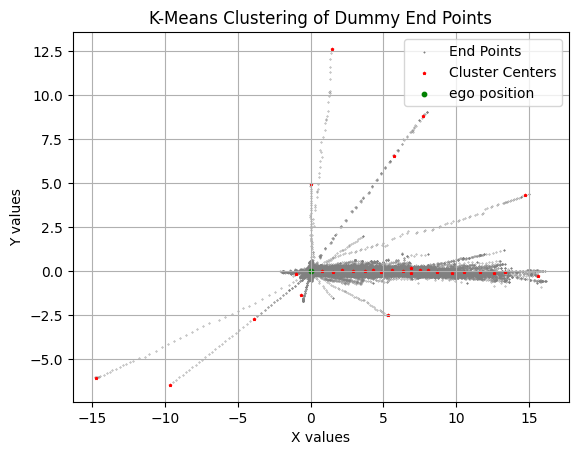

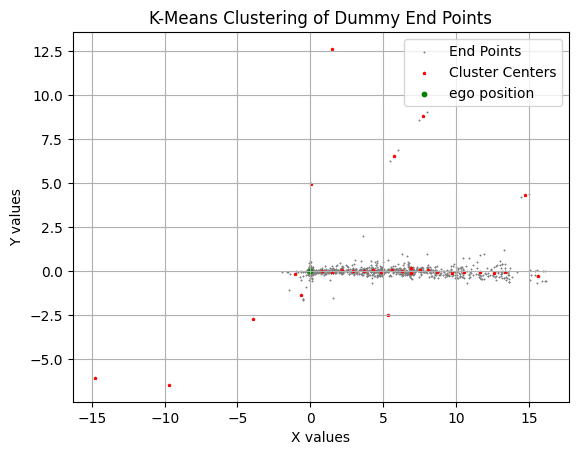

In [13]:
# get intention points for TYPE_PEDESTRIAN
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_DUMMY':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
pedestrian_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_DUMMY'] = pedestrian_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_pedestrian_mask = (all_center_objects_type_concat == 'TYPE_DUMMY')
filtered_pedestrian_trajs = all_center_gt_trajs_concat[filtered_pedestrian_mask]

filtered_pedestrian_trajs = filtered_pedestrian_trajs.reshape(-1, 4)
traj_x = filtered_pedestrian_trajs[:, 0].cpu().numpy()
traj_y = filtered_pedestrian_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Dummy End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Dummy End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import pickle
with open('../data/challenge/validation+ann_h1sf5s_cluster_32.pkl', 'wb') as file:
    pickle.dump(intention_points_dict, file)